In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayushuttarwar/makemore-names/names.txt


In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open('/kaggle/input/datasets/ayushuttarwar/makemore-names/names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
len(words)

32033

In [6]:
# building vocabulary and mapping to ints
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
# dataset building
block_size=3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [8]:
# data splitting
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_tr, Y_tr = build_dataset(words[:n1]) # 80%
X_val, Y_val = build_dataset(words[n1:n2])  # 10%
X_test, Y_test = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [19]:
# MLP neural net
n_embed = 10 # dimensionality of char embedding vector
n_hidden = 200 # #neurons in hidden layer

g = torch.Generator().manual_seed(1337)
C = torch.randn((vocab_size, n_embed), generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden), generator=g) * (5/3)/((n_embed * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) *0.1
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# params for batch normalization
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # total params
for p in parameters:
    p.requires_grad = True

12297


So earlier we facing a issue in *hpreact* that it's value getting too small and which is leading to no impact to passing it through the tanh  because the change is negligible.

We performed various techniques to prevent that but now we will be introducing batch normalization which totally prevents this issues and updates the weights values correctly.

A paper was released by google explaining the importance of **batch normalization** and also stated how to implement it. 

***Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift***


Formula,  
norm = (hpreact - mean) / (std. deviation) ** 2

In [20]:
# # training loop
# max_steps = 100000
# batch_size = 32
# lossi=[]

# for i in range(max_steps):
#     # minibatch
#     ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
#     Xb, Yb = X_tr[ix], Y_tr[ix]

#     # forward pass
#     emb = C[Xb] # convert to vectors
#     embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
#     # linear layer
#     hpreact = embcat @ W1 # + b1 # hidden layer

#     ### bias of hidden layer is getting canceled out while subtracting the mean from it, so the we have removed it because shifting is now controled using 'bnbias' value

#     # BatchNorm Layer
#     bnmeani = hpreact.mean(0, keepdim=True)
#     bnstdi = hpreact.std(0, keepdim=True)
#     hpreact = bngain * (hpreact - bnmeani) / (bnstdi) + bnbias

#     with torch.no_grad():
#         bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
#         bnstd_running = 0.999 * bnstd_running + 0.0001 * bnstdi

#     # non-linearity
#     h = torch.tanh(hpreact) # activation
#     logits = h @ W2 + b2 # output layer
#     loss = F.cross_entropy(logits, Yb) # loss

#     # backward pass
#     for p in parameters:
#         p.grad = None
#     loss.backward()

#     # update weights
#     lr = 0.1 if i < 50000 else 0.01 # step down
#     for p in parameters:
#         p.data += -lr*p.grad

#     # track stats
#     if i % 10000 == 0: 
#         print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
#     lossi.append(loss.log10().item())

#     # break

      0/ 100000: 3.3218
  10000/ 100000: 2.1306
  20000/ 100000: 2.2026
  30000/ 100000: 2.3348
  40000/ 100000: 2.3292
  50000/ 100000: 2.3810
  60000/ 100000: 2.0367
  70000/ 100000: 1.8857
  80000/ 100000: 2.0663
  90000/ 100000: 1.8836


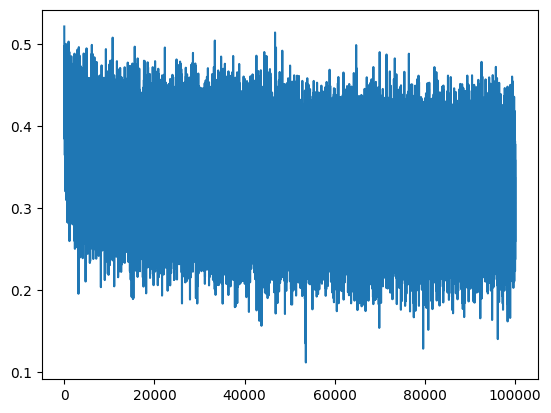

In [21]:
plt.plot(lossi)

When we deploy our neural net we don't it to recalculate the values of weights and biases after training is completed. We were ensuring that till adding batch normalization logic.

Because neural net now expects batches as a input.

So to prevent this we will perform a step to get correct results for single output:

In [17]:
# calibrate the batch norm at the end of training

with torch.no_grad():
    # pass the training set through
    emb = C[X_tr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

# now we have fixed (static) values for mean and std. deviation

After introducing the vars: *bnmean_running* and *bnstd_running* we have eliminated the need to explicit calibrate which we needed to run after training to enable single output generation

In [18]:
@torch.no_grad() # disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (X_tr, Y_tr),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]
    emb = C[x] # (N, block_size, n_embed)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embed)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / (hpreact.std(0, keepdim=True)) + bnbias
    hpreact = bngain * (hpreact - bnmean) / (bnstd) + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0972824096679688
val 2.1320595741271973


## Log Losses

#### Original
train: 2.15  
val: 2.19

#### After fixing the initial probability distribution
train: 2.07  
val: 2.13

#### After fixing the tanh layer saturation
train: 2.05  
val: 2.11

#### After adding batch norm layer
train: 2.097  
val: 2.13

## Pytorch-ifying the code

In [23]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [47]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training=True
        # params (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # unit normalization
        self.out = self.gamma * xhat + self.beta
        # update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return (self.gamma, self.beta)

In [48]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

#### updated code without batch normalization

In [49]:
n_embed = 10 # dimenality chars embedding vector
n_hidden = 100 # no. of neurons in hidden layer of MLP
g = torch.Generator().manual_seed(144235) # reproducibility

C = torch.randn((vocab_size, n_embed), generator=g)

# architecture
layers = [
    Linear(n_embed * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer (make less confident)
    layers[-1].weight *= 0.1
    # for all other (gain)
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # total params
for p in parameters:
    p.requires_grad = True

46497


In [50]:
# training loop
max_steps = 200000
batch_size = 32
lossi=[]
ud = []

for i in range(max_steps):
    # construct minibatch 
    ix = torch.randint(0, X_tr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = X_tr[ix], Y_tr[ix] # batch X, Y

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 10000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i%10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log().item() for p in parameters])

    if i >= 1000:
        break

      0/ 200000: 3.2994


layer 1 (      Tanh): mean -0.01, std 0.75, saturated: 17.53%
layer 3 (      Tanh): mean +0.00, std 0.71, saturated: 12.41%
layer 5 (      Tanh): mean -0.03, std 0.72, saturated: 11.28%
layer 7 (      Tanh): mean +0.00, std 0.73, saturated: 12.75%
layer 9 (      Tanh): mean +0.01, std 0.72, saturated: 11.78%


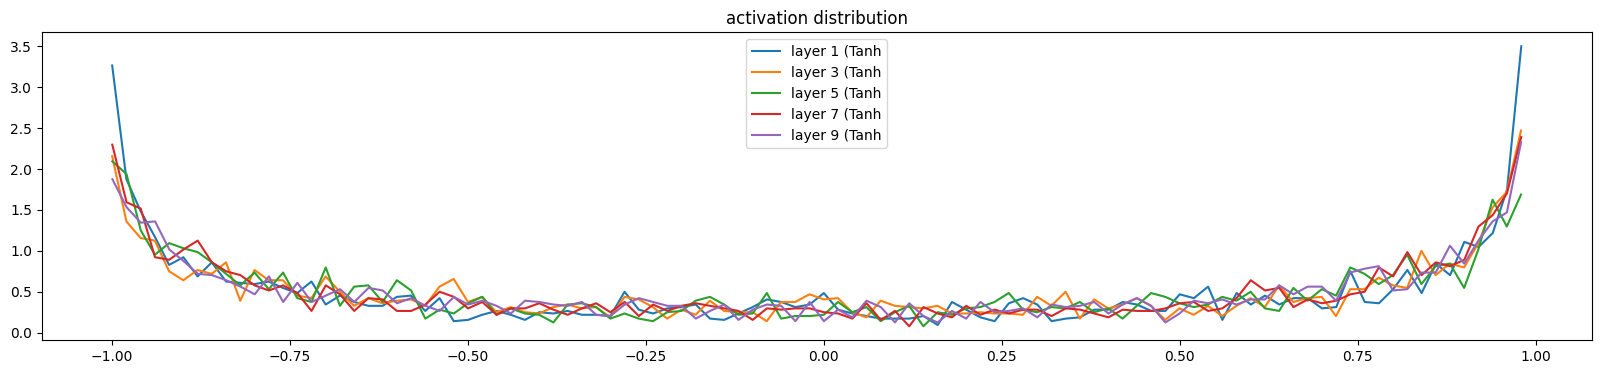

In [51]:
# visulaize histograms (ACTIVATION STATS IN FORWARD PASS)
plt.figure(figsize=(20, 4))
legends = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
    plt.legend(legends);
    plt.title('activation distribution')

layer 1 (      Tanh): mean +0.000003, std 3.231646e-03
layer 3 (      Tanh): mean -0.000005, std 3.037536e-03
layer 5 (      Tanh): mean +0.000034, std 2.890997e-03
layer 7 (      Tanh): mean +0.000051, std 2.673396e-03
layer 9 (      Tanh): mean +0.000011, std 2.224952e-03


Text(0.5, 1.0, 'gradient distribution')

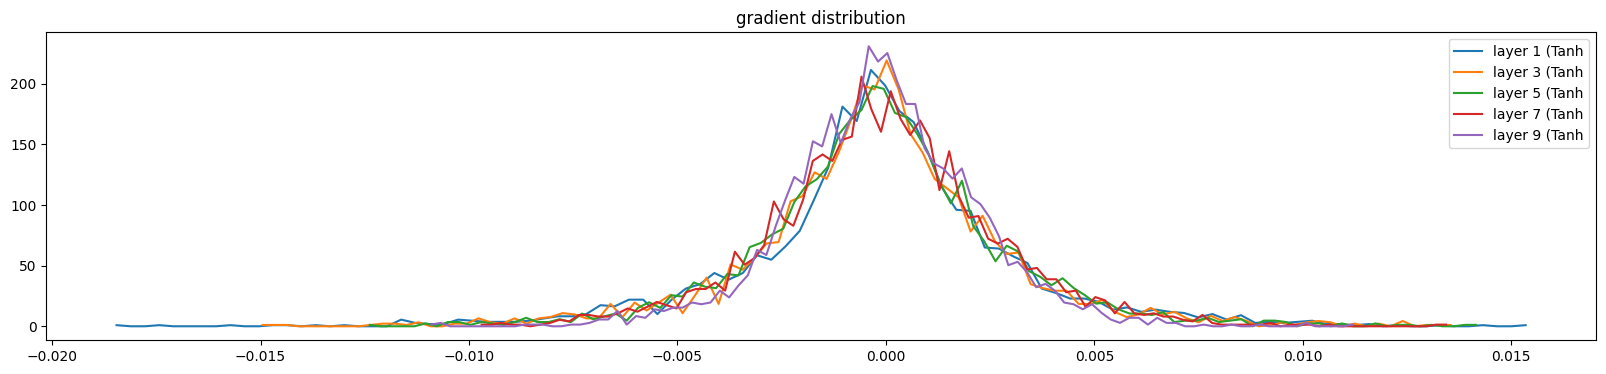

In [52]:
# visualize histograms (ACTIVATION STATS IN BACKWARD PASS)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000278 | std 1.107700e-02 | grad:data ratio 1.068428e-02
weight  (30, 100) | mean +0.000251 | std 1.012256e-02 | grad:data ratio 3.348913e-02
weight (100, 100) | mean -0.000022 | std 7.615497e-03 | grad:data ratio 4.547669e-02
weight (100, 100) | mean +0.000039 | std 6.918968e-03 | grad:data ratio 4.112900e-02
weight (100, 100) | mean -0.000031 | std 6.192180e-03 | grad:data ratio 3.615986e-02
weight (100, 100) | mean +0.000018 | std 5.191119e-03 | grad:data ratio 3.106970e-02
weight  (100, 27) | mean -0.000000 | std 2.155048e-02 | grad:data ratio 3.099649e-01


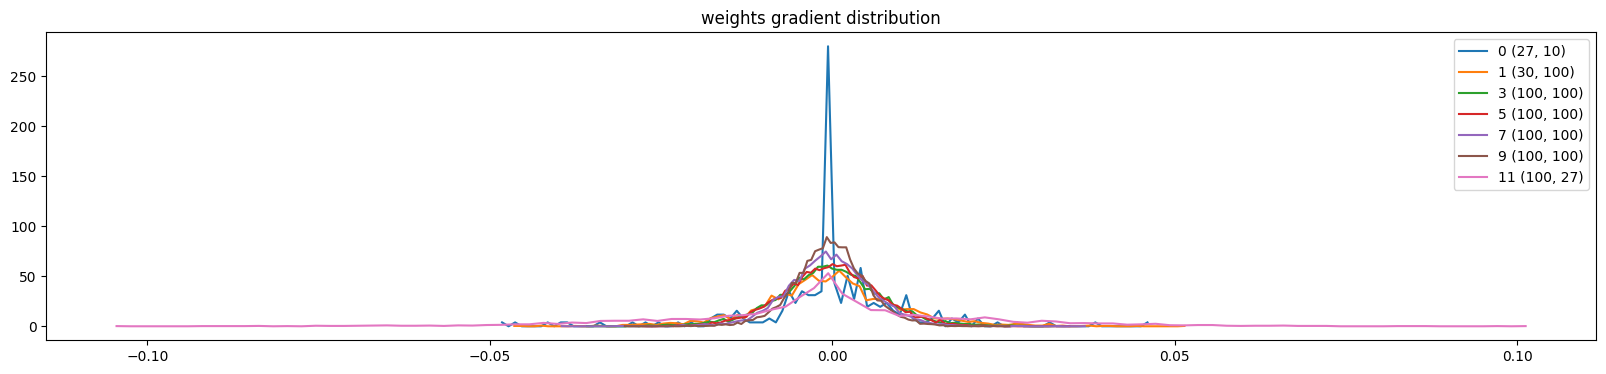

In [53]:
# visualize histograms (weight gradient stats)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

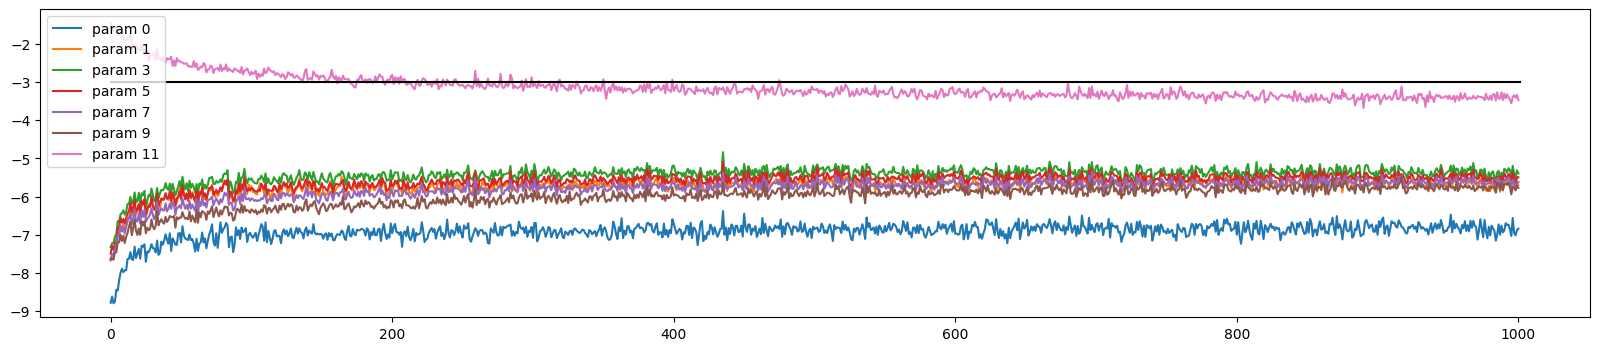

In [54]:
# WEIGHTS UPDATE THROUGHOUT THE TRAINING
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [44]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (X_tr, Y_tr),
    'val': (X_val, Y_val),
    'test': (X_test, Y_test),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 3.270502805709839
val 3.2704787254333496


### AFter applying batch normalization

In [55]:
n_embed = 10 # dimenality chars embedding vector
n_hidden = 100 # no. of neurons in hidden layer of MLP
g = torch.Generator().manual_seed(144235) # reproducibility

C = torch.randn((vocab_size, n_embed), generator=g)

# architecture
layers = [
    Linear(n_embed * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer (make less confident)
    layers[-1].gamma *= 0.1
    # for all other (gain)
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # total params
for p in parameters:
    p.requires_grad = True

47551


In [61]:
# training loop
max_steps = 200000
batch_size = 32
lossi=[]
ud = []

for i in range(max_steps):
    # construct minibatch 
    ix = torch.randint(0, X_tr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = X_tr[ix], Y_tr[ix] # batch X, Y

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 10000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i%10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log().item() for p in parameters])
        

      0/ 200000: 2.4299
  10000/ 200000: 2.1198
  20000/ 200000: 2.6149
  30000/ 200000: 1.9834
  40000/ 200000: 1.9301
  50000/ 200000: 1.9034
  60000/ 200000: 2.1305
  70000/ 200000: 1.9966
  80000/ 200000: 1.8048
  90000/ 200000: 2.1647
 100000/ 200000: 2.0821
 110000/ 200000: 2.0635
 120000/ 200000: 2.0414
 130000/ 200000: 1.8646
 140000/ 200000: 2.1351
 150000/ 200000: 2.0907
 160000/ 200000: 2.2367
 170000/ 200000: 2.1746
 180000/ 200000: 1.9417
 190000/ 200000: 2.2706


layer 2 (      Tanh): mean -0.02, std 0.65, saturated: 6.25%
layer 5 (      Tanh): mean +0.00, std 0.67, saturated: 7.41%
layer 8 (      Tanh): mean +0.01, std 0.68, saturated: 7.59%
layer 11 (      Tanh): mean +0.00, std 0.69, saturated: 6.56%
layer 14 (      Tanh): mean +0.00, std 0.69, saturated: 6.12%


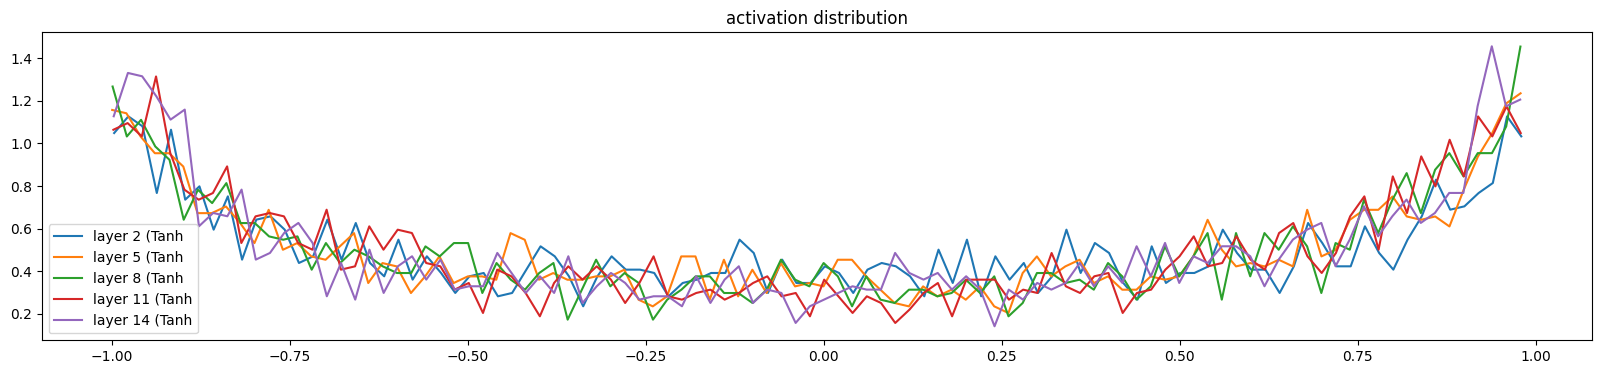

In [62]:
# visulaize histograms (ACTIVATION STATS IN FORWARD PASS)
plt.figure(figsize=(20, 4))
legends = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
    plt.legend(legends);
    plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 5.677900e-03
layer 5 (      Tanh): mean -0.000000, std 5.213941e-03
layer 8 (      Tanh): mean -0.000000, std 5.284096e-03
layer 11 (      Tanh): mean +0.000000, std 4.939485e-03
layer 14 (      Tanh): mean -0.000000, std 4.438253e-03


Text(0.5, 1.0, 'gradient distribution')

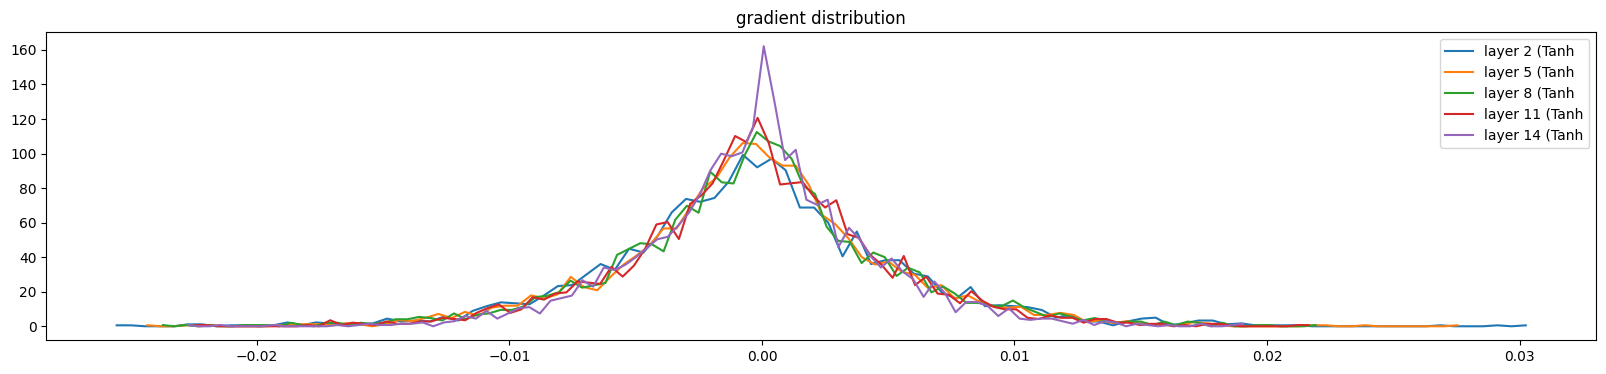

In [63]:
# visualize histograms (ACTIVATION STATS IN BACKWARD PASS)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.683467e-02 | grad:data ratio 1.610218e-02
weight  (30, 100) | mean -0.000052 | std 1.445233e-02 | grad:data ratio 4.545579e-02
weight (100, 100) | mean -0.000270 | std 1.107218e-02 | grad:data ratio 6.066635e-02
weight (100, 100) | mean +0.000056 | std 1.104856e-02 | grad:data ratio 6.074013e-02
weight (100, 100) | mean -0.000034 | std 1.046707e-02 | grad:data ratio 5.709681e-02
weight (100, 100) | mean +0.000122 | std 9.002979e-03 | grad:data ratio 5.057194e-02
weight  (100, 27) | mean -0.000101 | std 1.547308e-02 | grad:data ratio 7.454071e-02


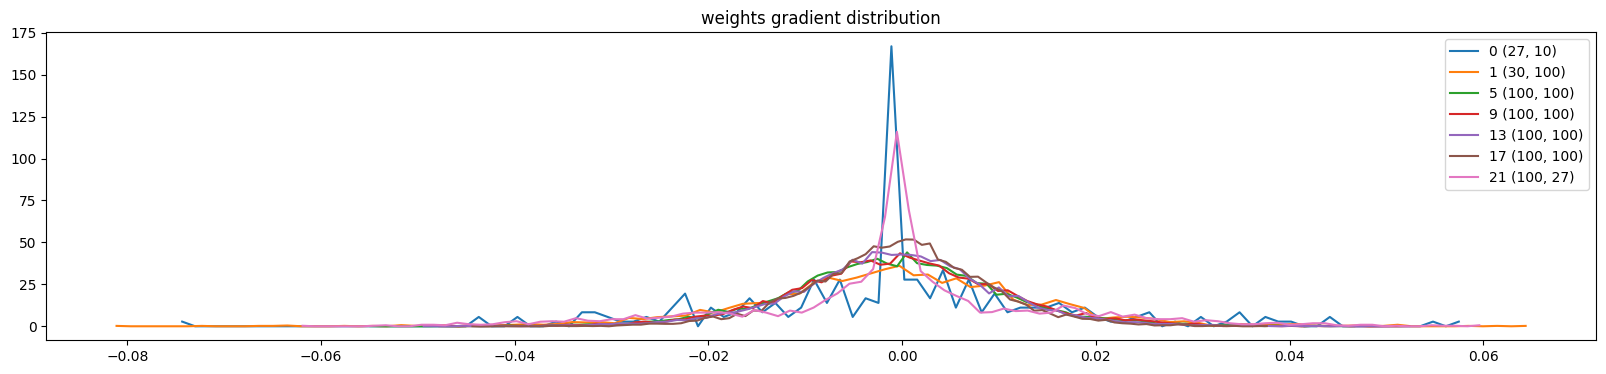

In [64]:
# visualize histograms (weight gradient stats)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

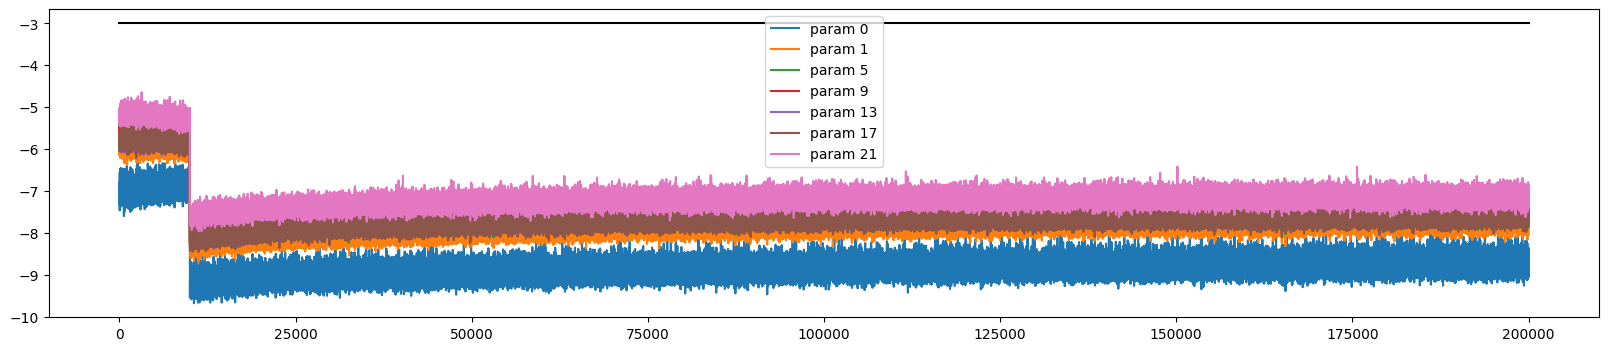

In [65]:
# WEIGHTS UPDATE THROUGHOUT THE TRAINING
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);